# IMPORT

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

path = r'D:\pandas\source files\project'

# rides.csv

In [2]:
df_r = pd.read_csv(path + r'\rides.csv', sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

In [3]:
df_r.columns = df_r.columns.str.lower().str.replace(' ', '_')
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              102255 non-null  int64  
 1   start_date      102255 non-null  object 
 2   end_date        102255 non-null  object 
 3   start_location  102255 non-null  object 
 4   start_district  102255 non-null  object 
 5   end_location    102255 non-null  object 
 6   end_district    102255 non-null  object 
 7   distance        101022 non-null  float64
 8   promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


In [4]:
df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_r['end_date'] = pd.to_datetime(df_r['end_date'])

### Дубликаты

#### Явные дубликаты

In [5]:
df_r.duplicated().sum()

np.int64(4883)

In [6]:
df_r.duplicated().mean()

np.float64(0.047753166104346975)

In [7]:
dups = df_r[df_r.duplicated(keep=False)]

In [8]:
dups.sort_values('id')

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
16,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
17,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
45,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
44,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
81,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
...,...,...,...,...,...,...,...,...,...
102181,197640,2023-07-31 21:43:19,2023-07-31 21:58:08,Кирова,Ленинский,Коммунальная,Юго-Восточный,2809.0,0
102183,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102184,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102205,197662,2023-07-31 21:57:30,2023-07-31 22:26:37,Дорожная,Юго-Восточный,Сиреневая,Юго-Восточный,3700.0,0


In [9]:
df_r[df_r.duplicated(keep=False)].shape

(9766, 9)

видим что строки сдвоены, 4883 дубликатов, 9766 наблюдений

In [10]:
df_r.drop_duplicates() # избавились от явных дубликатов, приступим к неявным

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


#### Неявные дубликаты

In [11]:
df_r['start_location'].unique()

array(['Шевченко', 'Чехова', 'Буденного', 'Труда', 'Первомайская',
       'Лесная', 'Пролетарская', 'Комарова', 'Западная', 'Свободы',
       'Коммунальная', 'Зеленая', 'Шоссейная', 'Центральная', 'буденного',
       'новая', 'Энтузиастов', 'ул.подгорная', 'Восточная', 'Лермонтова',
       'Школьная', 'Пушкина', 'подгорная', 'рябиновая', 'Солнечная',
       'Мичурина', 'ул труда', 'Партизанская', 'Вокзальная',
       'Комсомольская', 'майская', 'Красноармейская', 'Рабочая',
       'Почтовая', 'дачная', 'Заводская', 'Ломоносова', 'карла маркса',
       'Советская', 'Красная', 'Дзержинского', 'Рябиновая',
       'ул.советская', 'ул.энергетиков', 'Пионерская', 'ленина',
       'ул. сиреневая', 'гагарина', 'юбилейная', 'Цветочная',
       'ул. набережная', 'Сосновая', 'Спортивная', 'Новая', 'Ленина',
       'Полевая', 'ул. строительная', 'Майская', 'Озерная', 'ул.горького',
       'ул. восточная', 'пионерская', 'Энергетиков', 'ул.озерная',
       'южная', 'Некрасова', 'ул.молодежная', 'ул.

Если изучить то можно понять что тут записано 3 версии каждой из улиц, например: Буденного буденного ул.буденного

In [12]:
df_r['start_location'] = (
    df_r['start_location']
    .str.strip()
    .str.lower()
    .str.replace(r'\bул\.?\s*', '', regex=True)
    .str.replace(r'\s+', '', regex=True)
)

In [13]:
df_r['end_location'] = (
    df_r['end_location']
    .str.lower()
    .str.strip()
    .str.replace(r'\bул\.?\s+', '', regex=True)
    .str.replace(r'\s+', '', regex=True)
)

то же самое - проблема с форматом записи

In [14]:
df_r['start_district'].unique()

array(['Юго-Восточный', 'заречный', 'Октябрьский', 'Центральный',
       'Северо-Западный', 'Ленинский', 'ленинский', 'центральный',
       'Заречный', 'юго-восточный', 'северо-западный', 'октябрьский',
       'северо западный'], dtype=object)

In [15]:
df_r['start_district'] = (
    df_r['start_district']
    .str.lower()
    .str.strip()
    .str.replace(r'([а-я]+)\s+([а-я]+)', r'\1-\2', regex=True) 
)
df_r['start_district'].unique()

array(['юго-восточный', 'заречный', 'октябрьский', 'центральный',
       'северо-западный', 'ленинский'], dtype=object)

In [16]:
df_r['end_district'] = (
    df_r['end_district']
    .str.lower()
    .str.strip()
    .str.replace(r'([а-я]+)\s+([а-я]+)', r'\1-\2', regex=True) 
)
df_r['end_district'].unique()

array(['октябрьский', 'ленинский', 'северо-западный', 'юго-восточный',
       'центральный', 'заречный'], dtype=object)

### Выбросы

In [17]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              102255 non-null  int64         
 1   start_date      102255 non-null  datetime64[ns]
 2   end_date        101676 non-null  datetime64[ns]
 3   start_location  102255 non-null  object        
 4   start_district  102255 non-null  object        
 5   end_location    102255 non-null  object        
 6   end_district    102255 non-null  object        
 7   distance        101022 non-null  float64       
 8   promo           102255 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 7.0+ MB


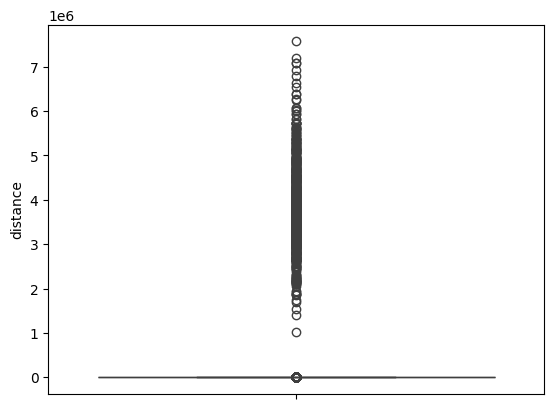

In [18]:
sns.boxplot(df_r, y='distance')
plt.show()

In [19]:
print(df_r['distance'].max())

7569789.0


смею предположить что в исходном файле distance на самом деле в мм. а не в м. Иначе большенство наших клинетов ездило от миллиона метров за поездку

In [20]:
df_r['distance'] = df_r['distance'] / 1000 # перевели в метры distance

In [21]:
max_dist = df_r['distance'].max()
row = df_r.loc[df_r['distance'] == max_dist]
print(row) # смотрим почему проехал больше всех. В целом за 42 минуты можно проехать 7569 метров

           id          start_date            end_date start_location  \
78664  175247 2023-07-10 09:57:49 2023-07-10 10:39:40         лесная   

      start_district end_location     end_district  distance  promo  
78664  юго-восточный    березовая  северо-западный  7569.789      1  


### Пропуски

In [22]:
df_r.isna().sum()

id                   0
start_date           0
end_date           579
start_location       0
start_district       0
end_location         0
end_district         0
distance          1233
promo                0
dtype: int64

# weather.csv

In [23]:
df_w = pd.read_csv(path + r'\weather.csv', sep=',', encoding='UTF-8')

## Предобработка данных

In [24]:
df_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


### PEP-8 и типы данных

In [25]:
df_w.columns = df_w.columns.str.lower().str.replace(' ', '_')

In [26]:
df_w.info() #,°C,mm,km/h,km/h,%,min

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   datetime             3672 non-null   object
 1   temperature          3618 non-null   object
 2   precipitation_total  3643 non-null   object
 3   wind_gust            3673 non-null   object
 4   wind_speed           3657 non-null   object
 5   cloud_cover_total    3653 non-null   object
 6   sunshine_duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


In [37]:
df_w = df_w.drop(0)
df_w.head(5) # строка с индексом 0 имеет записи об еденицах измерения, нужно её удалить 

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
1,2023-04-01 00:00:00,8.740245,0.1,48.6,21.638964,90,0
2,2023-04-01 01:00:00,9.040245,0.2,55.44,22.493519,74,0
3,2023-04-01 02:00:00,8.880245,0.3,55.8,22.26477,72,0
4,2023-04-01 03:00:00,8.690246,0.3,55.44,21.94524,77,0
5,2023-04-01 04:00:00,8.630245,0.3,48.96,22.42427,78,0


In [28]:
df_w['datetime'].unique() # нам нужно поменять формат на datetime

array([nan, '2023-04-01T00:00:00', '2023-04-01T01:00:00', ...,
       '2023-08-31T21:00:00', '2023-08-31T22:00:00',
       '2023-08-31T23:00:00'], dtype=object)

#### приведение типов данных

In [51]:
df_w['datetime'] = pd.to_datetime(df_w['datetime'])
df_w['temperature'] = df_w['temperature'].astype(float) # температура у нас не string а float должна быть
df_w['precipitation_total'] = df_w['precipitation_total'].astype(float) # тоже тип float потому что наблюдения: 1.9 (пример)
df_w['wind_gust'] = df_w['wind_gust'].astype(float) 
df_w['wind_speed'] = df_w['wind_speed'].astype(float)
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].astype(float) # на первый взгляд целочисленные, но там еще есть десятичные
df_w['sunshine_duration'] = df_w['sunshine_duration'].astype(float) # данные в вещественном формате

### Дубликаты

#### Явные дубликаты

In [54]:
df_w.duplicated().sum() # явных дубликатов не обнаружено

np.int64(0)

#### Неявные дубликаты

In [56]:
df_w['temperature'].unique()

array([ 8.740245,  9.040245,  8.880245, ..., 14.290245, 15.410245,
       19.980246])

### Выбросы

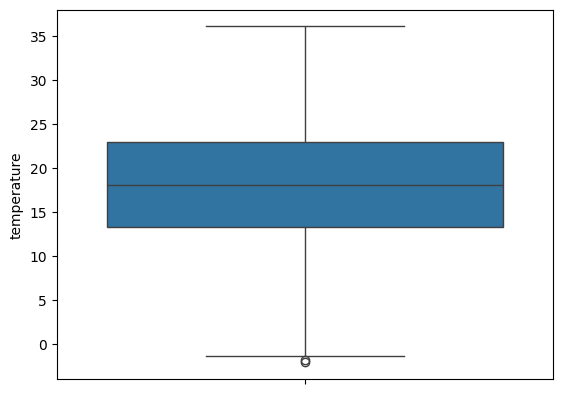

In [57]:
sns.boxplot(df_w, y='temperature')
plt.show()

In [59]:
df_w['temperature'].min()

np.float64(-2.0797548)

In [63]:
df_w.loc[df_w['temperature'] == -2.0797548]

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
126,2023-04-06 05:00:00,-2.079755,0.0,10.440001,3.075841,6.6,2.131111


In [69]:
df_w.loc[(df_w['datetime'] >= '2023-04-06') & (df_w['datetime'] <= '2023-04-06 09:00:00')] # не выброс, температура ночью упала

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
121,2023-04-06 00:00:00,2.620245,0.0,5.400000,2.545584,3.0,0.000000
122,2023-04-06 01:00:00,1.070245,0.0,6.479999,3.671294,1.0,0.000000
123,2023-04-06 02:00:00,-0.269755,0.0,8.280000,3.671294,1.0,0.000000
124,2023-04-06 03:00:00,-1.319755,0.0,9.720000,3.415260,7.2,0.000000
125,2023-04-06 04:00:00,-1.869755,0.0,10.080000,3.075841,18.6,0.000000
126,2023-04-06 05:00:00,-2.079755,0.0,10.440001,3.075841,6.6,2.131111
127,2023-04-06 06:00:00,-0.029755,0.0,10.440001,4.198285,9.3,54.363636
128,2023-04-06 07:00:00,3.270246,0.0,14.040000,4.213692,18.6,48.727276
129,2023-04-06 08:00:00,6.360245,0.0,14.040000,3.960000,31.0,41.212120
130,2023-04-06 09:00:00,8.610246,0.0,15.119999,4.896529,79.0,12.121214


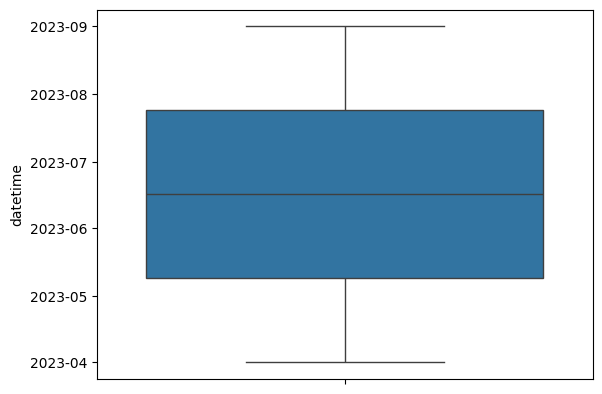

In [70]:
sns.boxplot(df_w, y='datetime')
plt.show()

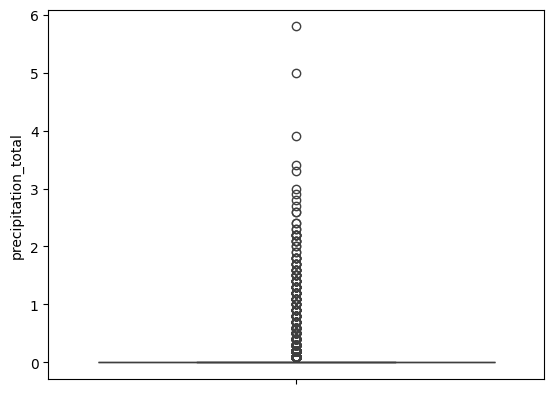

In [71]:
sns.boxplot(df_w, y='precipitation_total')
plt.show()

In [76]:
df_w.loc[df_w['precipitation_total'] > 4] # скорее всего просто много осадков, не выброс, ничего такого

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
1984,2023-06-22 15:00:00,23.480246,5.8,50.760000,11.808878,35.0,38.787880
1985,2023-06-22 16:00:00,24.860245,5.0,38.519997,18.214718,32.0,40.606064


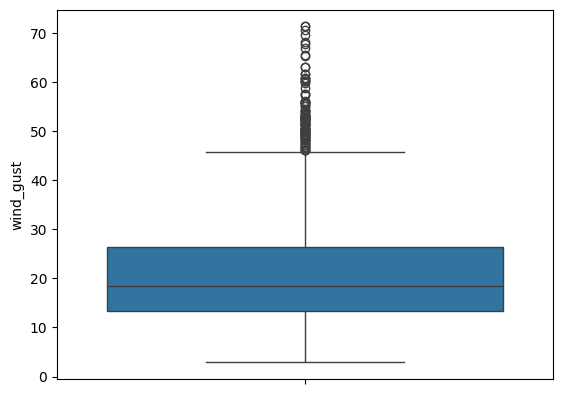

In [72]:
sns.boxplot(df_w, y='wind_gust')
plt.show()

In [74]:
df_w.loc[df_w['wind_gust'] >= 60] # думаю, что адекватные порывы

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
9,2023-04-01 08:00:00,8.640245,0.5,63.000000,20.371038,92.0,4.242425
10,2023-04-01 09:00:00,8.730246,0.6,60.120003,23.838959,88.0,6.666666
11,2023-04-01 10:00:00,9.150246,0.6,60.120003,23.199759,98.0,0.606061
14,2023-04-01 13:00:00,10.620245,0.4,60.479996,18.472595,98.0,0.606061
279,2023-04-12 14:00:00,13.800245,1.4,63.000000,18.837324,98.0,0.606061
280,2023-04-12 15:00:00,12.250245,0.9,60.839996,17.884428,80.0,9.696970
2964,2023-08-02 11:00:00,25.760244,0.0,68.039990,29.966620,81.0,10.909091
2965,2023-08-02 12:00:00,26.970245,0.0,71.280000,28.008370,80.0,11.515152
2966,2023-08-02 13:00:00,27.540245,0.0,70.560000,24.985659,70.0,17.575756
2967,2023-08-02 14:00:00,27.630245,0.0,61.560000,27.288855,61.0,23.030302


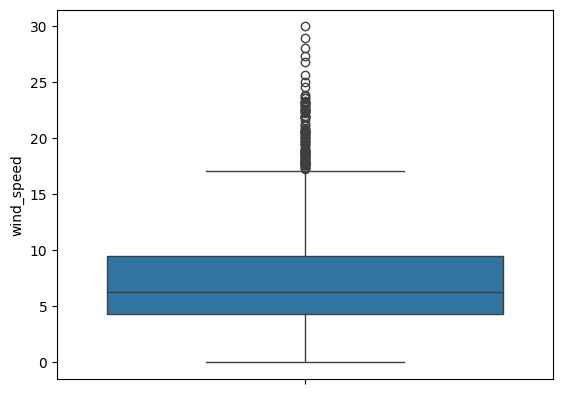

In [77]:
sns.boxplot(df_w, y='wind_speed')
plt.show() 

In [79]:
df_w.loc[df_w['wind_speed'] > 25] # думаю что все сходится, ветер может быть таким, не выбросы 

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
2963,2023-08-02 10:00:00,23.900246,0.0,49.320000,28.954834,90.0,5.454544
2964,2023-08-02 11:00:00,25.760244,0.0,68.039990,29.966620,81.0,10.909091
2965,2023-08-02 12:00:00,26.970245,0.0,71.280000,28.008370,80.0,11.515152
2967,2023-08-02 14:00:00,27.630245,0.0,61.560000,27.288855,61.0,23.030302
2968,2023-08-02 15:00:00,27.620245,0.0,52.920000,26.758923,67.0,19.393942
2989,2023-08-03 12:00:00,22.140245,0.0,60.839996,25.600533,55.0,26.666664


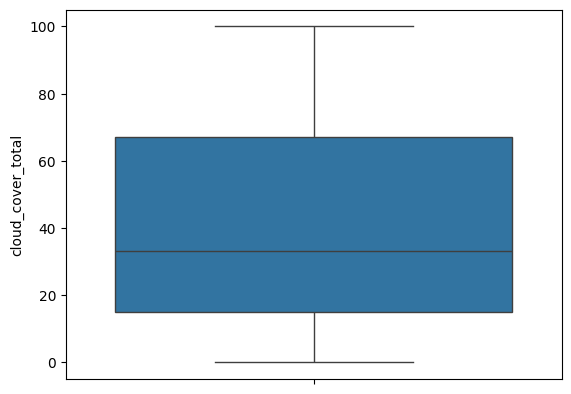

In [80]:
sns.boxplot(df_w, y='cloud_cover_total')
plt.show() # тут у нас в %, выбросов, естественно, нет

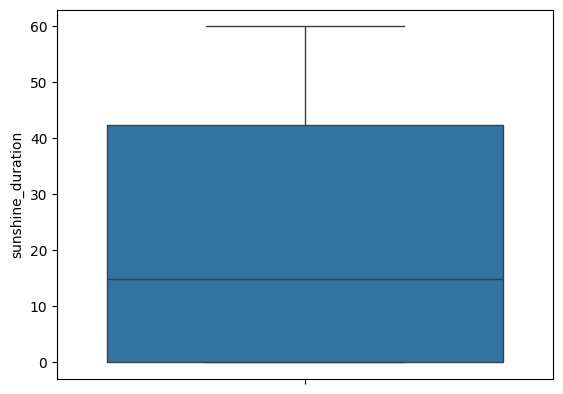

In [81]:
sns.boxplot(df_w, y='sunshine_duration')
plt.show() # отлично, выбросов нет, у нас максимальное значение солнечного сияния 60 минут, что закономерно, учитывая что наблюдения за час